# Valutazione del modello formale

Questo documento raccoglie la valutazione del modello di scheduling policy-driven
definito nel Capitolo 3. Il modello è stato eseguito attraverso una implementazione
di riferimento in Python che ne traduce una per una le definizioni: il calcolo del
requisito effettivo, l'intersezione delle giurisdizioni, la selezione dei nodi
ammissibili e i due indicatori di ottimizzazione. L'implementazione non contiene
code, latenze né alcuna componente dell'infrastruttura Kubernetes.

## Che cosa si valuta qui, e che cosa no

La valutazione del lavoro si articola su due strumenti che rispondono a domande
distinte e non sovrapponibili.

Il **prototipo Kubernetes** consente di misurare quanto costa applicare le politiche:
latenze di ammissione, di traduzione e di scheduling, e tempo di attesa dei task
bloccati. Sono grandezze temporali, e solo un sistema reale può produrle.

L'**implementazione di riferimento**, oggetto di questo documento, consente di
misurare che cosa le politiche fanno allo spazio delle soluzioni: quanti nodi restano
ammissibili, quali politiche risultano vincolanti, come lo stato accumulato sui nodi
degradi la schedulabilità e quali configurazioni del cluster ne limitino gli effetti.
Sono proprietà del modello, indipendenti dall'hardware, osservabili su griglie di
parametri e su dimensioni di cluster che un ambiente di prova non raggiungerebbe.

Nessuna misura di tempo assoluto compare in questo documento.

## Struttura

La **Parte I** valuta lo spazio delle soluzioni. Ogni task è esaminato su un cluster
pulito, senza tracce lasciate da esecuzioni precedenti. Si misura quanto le politiche
di configurazione, ovvero il vincolo sulle proprietà dei nodi, quello geografico e
quello sui dati statici, riducano l'insieme dei nodi su cui un task può essere
eseguito. Dopo una misura complessiva delle tre politiche in composizione, due
sezioni ne isolano una ciascuna per misurarne la restrittività intrinseca.

La **Parte II** valuta la dinamica dell'assegnazione. Lo stesso carico viene eseguito
come sequenza ordinata, e ogni task assegnato lascia sul nodo che lo esegue una
traccia dei contesti a cui ha avuto accesso. Si misura quanto la politica di Chinese
Wall blocchi i task successivi, come la sanificazione dei nodi mitighi il fenomeno e
quale configurazione del cluster lo elimini.

La separazione fra le due parti non è espositiva ma metodologica: è ciò che consente
di attribuire ogni risultato o alla configurazione del cluster o allo stato
accumulato, e non a una miscela indistinguibile dei due.

## Nozioni introdotte dalla valutazione

I simboli del modello sono quelli del Capitolo 3 e non vengono ridefiniti. Sono
invece elencati qui i parametri e le nozioni introdotti dalla sola valutazione, che
compaiono negli assi dei grafici e nelle tabelle.

**Il passo.** Unità di conteggio della Parte II: un passo corrisponde a un task
sottomesso. Non è una unità di tempo. La durata dei task e il periodo di
sanificazione sono espressi in passi.

**Densità dei conflitti, $\rho$.** L'insieme $X_{conf}$ è generato come grafo casuale
sui contesti, e $\rho$ è la frazione delle coppie possibili che vi appartengono. Con
trenta contesti le coppie possibili sono 435, quindi $\rho = 0.1$ corrisponde a circa
44 coppie in conflitto. Si usa una densità anziché un conteggio assoluto perché il
numero di coppie cresce quadraticamente nel numero di contesti, e la densità mantiene
i risultati confrontabili se questo cambia.

**Periodo di sanificazione, $S$.** Ogni $S$ passi tutti i nodi che portano una
impronta contestuale non vuota vengono posti in sanificazione.

**Soglia di sanificazione, $\theta$.** Un nodo viene posto in sanificazione quando la
sua impronta contestuale raggiunge $\theta$ contesti distinti, verificando la
condizione a ogni passo.

**Numero di proprietà, $P$.** Quante proprietà astratte il modello definisce. Il
Capitolo 3 non ne fissa il numero, e una delle sezioni misura come la restrittività
del vincolo dipenda da esso.

**Fattore di replica del cluster, $r$.** Il cluster è costruito replicando $r$ volte
un template di composizione fissa. Il template stabilisce quali classi di proprietà
esistono, in quali proporzioni e in quali località; il fattore di replica ne stabilisce
la dimensione. Poiché replicare il template replica anche i nodi di ogni classe e di
ogni località, la composizione resta costante al variare della dimensione, e ogni
effetto osservato facendo crescere $r$ è attribuibile alla sola scala.

**Composizioni del cluster.** Due composizioni sono impiegate come termini di
confronto. Il cluster *stratificato* estrae la classe di ciascun nodo uniformemente
dal reticolo delle classi possibili, e rappresenta una infrastruttura in cui le
capacità sono distribuite in modo omogeneo. Il cluster *realistico* estrae ogni
proprietà in modo indipendente con pesi decrescenti, così che i nodi di fascia bassa
siano comuni e quelli di fascia alta scarsi.

Una terza composizione, in cui ogni nodo offre il livello massimo di ogni proprietà,
è stata scartata: in essa il vincolo sulle proprietà non può escludere alcun nodo, e
la sua valutazione produrrebbe una costante priva di informazione.

**Dati replicati e dati fermi.** Sono le due modalità con cui il piazzamento dei
dataset viene trattato quando il cluster viene ingrandito. Con i **dati replicati**
ogni copia di un nodo riceve anche i dataset che quel nodo ospitava, quindi cresce sia
la capacità di calcolo sia il numero di posizioni in cui i dati risiedono. Con i
**dati fermi** i dati restano sui nodi originali, che è ciò che accade quando si
aggiungono nodi di calcolo senza intervenire sullo strato di memorizzazione.

**Task bloccati dallo stato.** Grandezza osservata in tutta la Parte II: i task per
cui la sola configurazione del cluster avrebbe lasciato dei candidati, ma che non ne
trovano alcuno a causa delle tracce accumulate o dei nodi temporaneamente sottratti
perché in sanificazione. Isolarla è ciò che separa l'effetto della dinamica da quello
della configurazione, già misurato nella Parte I.

## Metodologia

**Trattamento dei task bloccati.** Un task che al proprio passo non trova alcun nodo
ammissibile viene contato come bloccato e non viene riprovato. Riaccodarlo
introdurrebbe una coda, e il comportamento della coda è ciò che si misura sul
prototipo. Qui si misura l'ammissibilità istantanea, ovvero se lo stato lasciato dai
task precedenti consenta a questo di partire nel momento in cui viene sottomesso.

**Ripetizioni e statistiche riportate.** Ogni configurazione è eseguita con dieci semi
indipendenti. Il seme determina la composizione del cluster, gli attributi e il
piazzamento dei dataset, il grafo dei conflitti e l'ordine del batch. I grafici
riportano la mediana fra i semi e una banda che copre lo scarto interquartile, ovvero
il cinquanta per cento centrale delle esecuzioni. La mediana è preferita alla media
perché diverse delle distribuzioni osservate sono asimmetriche.

**Isolamento delle variabili.** Ogni ambito attinge da un flusso pseudocasuale
indipendente. Cambiare il numero di task non altera la composizione del cluster,
cambiare la densità dei conflitti non altera i dataset, cambiare la composizione del
cluster non altera gli attributi dei dataset ma soltanto il loro piazzamento, che
dipende necessariamente dal cluster. Ogni esperimento fa variare un solo asse rispetto
alla configurazione di riferimento.

**Disegni appaiati.** Dove il confronto avviene fra valori crescenti di uno stesso
parametro si è preferito un disegno appaiato a uno indipendente. Nell'esperimento
sull'imbuto delle politiche ogni task è generato con la richiesta più lunga e valutato
sui prefissi della propria richiesta; nell'esperimento sulla dimensionalità delle
proprietà il cluster è generato una volta sola e proiettato su sottoinsiemi delle
proprietà. In entrambi i casi la variabile in esame cambia mentre tutto il resto resta
identico, il che elimina la varianza fra campioni diversi.

**Estrazione dei requisiti.** Sia i task sia i dataset dichiarano per ciascuna
proprietà un livello richiesto, estratto con pesi decrescenti anziché entro un tetto
rigido. La scelta è necessaria perché il requisito effettivo è un minimo maggiorante
su tutte le proprietà di tutti i dataset richiesti, e aggrega quindi fino a nove
estrazioni indipendenti: un livello estratto raramente per singolo dataset diventa
comune a livello di task. Con un tetto rigido il livello massimo sarebbe risultato o
impossibile o tipico, senza valori intermedi.

**Politica di autorizzazione.** Il carico è generato in modo che la politica di
autorizzazione non intervenga mai: un soggetto richiede solo dataset per i cui
contesti è autorizzato. Quella politica non dipende dalla configurazione del cluster,
e lasciarla intervenire avrebbe misurato la distribuzione del generatore anziché una
proprietà del modello. Resta comunque applicata nella pipeline.

## Configurazione di riferimento

Tutti gli esperimenti partono dalla stessa configurazione e ne deviano lungo un solo
asse. La cella seguente la stampa direttamente dal codice, così che la documentazione
non possa divergere dai parametri effettivamente impiegati.

I valori sono stati calibrati in modo che nessuna politica risulti né inerte né
dominante. Una configurazione in cui una politica rifiuta la quasi totalità dei task
renderebbe invisibile ogni altro effetto; una in cui non rifiuta mai nulla non
consentirebbe di misurarne il contributo.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

from simulator.config import BASELINE

RESULTS = Path(".tmp/results")
FIGURES = Path(".tmp/figures")
FIGURES.mkdir(exist_ok=True)

print(BASELINE.to_json())

{
  "cluster": {
    "replication_factor": 1,
    "slots_per_node": -1,
    "template": "realistic",
    "template_size": 36
  },
  "contexts": {
    "auth_size": 1,
    "conflict_density": 0.1,
    "n_contexts": 30
  },
  "datasets": {
    "beta_weights": [
      20,
      20,
      12,
      1
    ],
    "geo_umbrella_fraction": 0.85,
    "n_datasets": 150,
    "placement_replication": 3,
    "public_fraction": 0.1,
    "replicate_placement": true,
    "size_max": 4096.0,
    "size_min": 128.0,
    "static_fraction": 0.25
  },
  "geo": {
    "locations_per_region": 4,
    "n_regions": 2,
    "region_prefix": "r",
    "umbrella_name": "global"
  },
  "properties": {
    "max_levels": {
      "computation": 3,
      "network": 3,
      "security": 3
    }
  },
  "sanitization": {
    "period": 50,
    "strategy": "periodic",
    "threshold": 3
  },
  "scoring": {
    "prop_weights": {},
    "w_prop": 1.0,
    "w_transfer": 2.0
  },
  "seed": 0,
  "workload": {
    "beta_weights": [
   

Il significato dei parametri principali e la ragione del valore scelto.

**Proprietà dei nodi.** Tre proprietà astratte con tre livelli ciascuna, sul modello
delle risorse omonime del prototipo. Il reticolo delle classi possibili ha quindi
ventisette elementi.

**Cluster.** Template di trentasei nodi, replicato una sola volta salvo negli
esperimenti che fanno variare la scala. La dimensione è scelta in rapporto al
reticolo: con ventisette classi possibili consente al cluster stratificato di coprire
l'intero reticolo con una ridondanza modesta anziché campionarlo in modo sparso. La
composizione di riferimento è quella realistica.

**Dataset.** Centocinquanta dataset, di cui un quarto statici e un decimo privi di
contesto, ciascuno residente su tre nodi del template. La numerosità è dimensionata in
modo che ogni soggetto possa formulare le richieste più lunghe impiegate negli
esperimenti: poiché ogni soggetto è autorizzato a un solo contesto, può richiedere
soltanto i dataset di quel contesto più quelli privi di contesto, e una popolazione
troppo ridotta restringerebbe silenziosamente il carico ai pochi soggetti che
qualificano.

**Giurisdizioni.** Due regioni da quattro località ciascuna, più un gruppo che le
comprende entrambe. L'ottantacinque per cento dei dataset dichiara il gruppo ampio e
il restante una regione specifica. Il valore è alto di proposito: poiché la
giurisdizione effettiva è una intersezione, estrarre le regioni in modo indipendente
la renderebbe vuota nella maggior parte dei casi, e i rifiuti in traduzione
maschererebbero ogni altro effetto.

**Contesti.** Trenta contesti e un soggetto per contesto.

**Carico.** Tremila task per esecuzione nella Parte I e duemila nella Parte II,
ciascuno con da uno a tre dataset, salvo negli esperimenti che richiedono richieste
più lunghe. Nella Parte II ogni task occupa il nodo per dieci passi.

In [ ]:
plt.rcParams.update({
    "figure.figsize": (7.8, 4.4),
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.axisbelow": True,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "font.size": 10,
    "lines.linewidth": 1.9,
    "lines.markersize": 5.5,
})

BLU, ARANCIO, VERDE, ROSSO, VIOLA, GRIGIO = (
    "#2f6f9f", "#e08214", "#3f8f55", "#c0392b", "#7b5ea7", "#8a8a8a")

TRANSLATION_CAUSES = {"auth", "geo_empty", "static_empty"}
TEMPLATE_NAMES = {"stratified": "stratificato", "realistic": "realistico"}
TEMPLATE_ORDER = ["stratified", "realistic"]
TEMPLATE_COLOURS = {"stratified": BLU, "realistic": ROSSO}


# Loads a result file and adds the derived columns used by the figures.
def load(name):
    df = pd.read_csv(RESULTS / f"{name}.csv")
    if "cause" not in df.columns:
        return df

    df["rifiutato_in_traduzione"] = df.cause.isin(TRANSLATION_CAUSES)
    for cause in ("prop", "geo", "static", "wall", "capacity", "sanitizing",
                  "geo_empty", "static_empty"):
        df[f"causa_{cause}"] = df.cause == cause

    # The funnel columns are meaningless for a task rejected before any node
    # was inspected, so they are left undefined rather than set to zero.
    inspected = ~df.rifiutato_in_traduzione
    for column, source in (("frazione_prop", "n_after_prop"),
                           ("frazione_geo", "n_after_geo"),
                           ("frazione_static", "n_after_static"),
                           ("frazione_ammissibili", "n_admissible")):
        df[column] = np.where(inspected, df[source] / df.n_nodes, np.nan)

    df["richiede_statici"] = df.n_static_datasets > 0
    return df


# Aggregates per configuration and per seed: one row per run.
def per_seme(df, keys, metrics):
    return df.groupby(keys + ["seed"], observed=True).agg(**metrics).reset_index()


# Median across seeds with the interquartile range, used as the spread band.
def sintesi(per_seed_df, keys, column):
    g = per_seed_df.groupby(keys, observed=True)[column]
    return g.agg(mediana="median",
                 q1=lambda x: x.quantile(0.25),
                 q3=lambda x: x.quantile(0.75)).reset_index()


# Draws one curve with its spread band across seeds.
def curva(ax, per_seed_df, x, y, colour, label, marker="o", style="-"):
    b = sintesi(per_seed_df, [x], y).sort_values(x)
    ax.plot(b[x], b.mediana, style, marker=marker, color=colour, label=label)
    ax.fill_between(b[x], b.q1, b.q3, color=colour, alpha=0.14, linewidth=0)
    return b


def asse_percentuale(ax, axis="y", decimals=0):
    fmt = PercentFormatter(xmax=1, decimals=decimals)
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)


def salva(fig, name):
    fig.savefig(FIGURES / f"{name}.pdf")
    fig.savefig(FIGURES / f"{name}.png")


print("funzioni di supporto pronte")

funzioni di supporto pronte


# Parte I. Lo spazio delle soluzioni

Questa parte misura quanto le politiche riducano l'insieme dei nodi su cui un task può
essere eseguito, prima che qualunque stato si accumuli. Il cluster è pulito, i task
sono valutati uno per uno e in modo indipendente, e nessun task lascia tracce che
possano influenzare i successivi.

Le politiche agiscono in due punti distinti della pipeline, e la distinzione è
rilevante perché le due situazioni si correggono in modo opposto.

Alcuni rifiuti avvengono in **traduzione**, prima che un solo nodo venga esaminato.
Accade quando la giurisdizione effettiva risulta vuota, ovvero quando i dataset
richiesti sono soggetti a giurisdizioni la cui intersezione è vuota, e quando è vuota
l'intersezione dei nodi che ospitano i dataset statici richiesti. In entrambi i casi
il rifiuto dipende dalla sola richiesta, e nessuna quantità di nodi aggiuntivi lo
risolve.

Altri rifiuti avvengono in **filtraggio**, escludendo i nodi uno per uno. Qui il
vincolo è la composizione del cluster, e aggiungere nodi adeguati produce un
beneficio.

## Quanto le politiche restringono l'insieme dei nodi ammissibili

**Che cosa si misura.** Le politiche sono valutate in ordine fisso, prima il vincolo
sulle proprietà, poi quello geografico, poi quello sui dati statici, e ogni nodo
escluso è attribuito alla prima politica che non soddisfa. Il conteggio dopo ciascuna
politica è quindi il numero di nodi ancora ammissibili dopo quella e tutte le
precedenti. La sequenza si legge come un imbuto, e la distanza fra due curve
consecutive è il contributo marginale della singola politica, dato l'ordine di
valutazione.

**Perché il numero di dataset richiesti è la variabile scelta.** È l'unico parametro
in gioco che dipende da chi scrive il task e non da chi amministra il cluster. Il
numero di nodi, le loro classi di proprietà e la posizione dei dati sono decisioni
dell'operatore dell'infrastruttura, mentre quante sorgenti un task aggreghi è una
scelta di chi lo sottomette.

**Perché l'andamento decrescente è atteso prima ancora di misurarlo.** Non si tratta
di una ipotesi da verificare ma di una conseguenza algebrica degli operatori del
modello. Il requisito effettivo è un minimo maggiorante sui dataset richiesti, e
aggiungere un elemento non può abbassare un massimo; la giurisdizione effettiva e
l'intersezione dei nodi che ospitano i dataset statici sono intersezioni, e aggiungere
un insieme non può allargare una intersezione. Ne segue che per ogni task e per ogni
dataset aggiuntivo l'insieme ammissibile può soltanto restringersi, qualunque sia la
distribuzione dei dati. L'esperimento non serve dunque a stabilire se il pool si
restringa, ma a quantificare di quanto, che è una grandezza legittimamente dipendente
dal carico.

**Configurazione di partenza.** Configurazione di riferimento in tutti i suoi
parametri, con la sola eccezione della lunghezza della richiesta, portata a cinque
dataset per consentire il disegno appaiato. Nessun conflitto interviene, poiché il
cluster è pulito.

**Che cosa varia.** Il numero di dataset richiesti, da uno a cinque, su entrambe le
composizioni di cluster. Il disegno è appaiato: ogni task è generato con cinque
dataset e valutato sui prefissi di lunghezza uno, due e così via della propria
richiesta, cosicché il confronto tenga fissi il task, il soggetto e i dataset e
aggiunga un vincolo alla volta.

**Un campione costante.** Un task rifiutato in traduzione non contribuisce all'imbuto,
poiché nessun nodo viene esaminato. Poiché il rifiuto in traduzione è monotono nella
lunghezza del prefisso, un task che sopravvive al prefisso più lungo sopravvive a
tutti quelli più corti: restringere l'analisi a questi task fornisce un campione
identico a ogni lunghezza. Senza questo accorgimento la curva sarebbe calcolata su un
insieme progressivamente più piccolo e composto dai task meno vincolati, e potrebbe
risalire artificialmente. La quota di task rifiutati in traduzione è riportata a parte
nel secondo grafico, perché costituisce essa stessa un risultato.

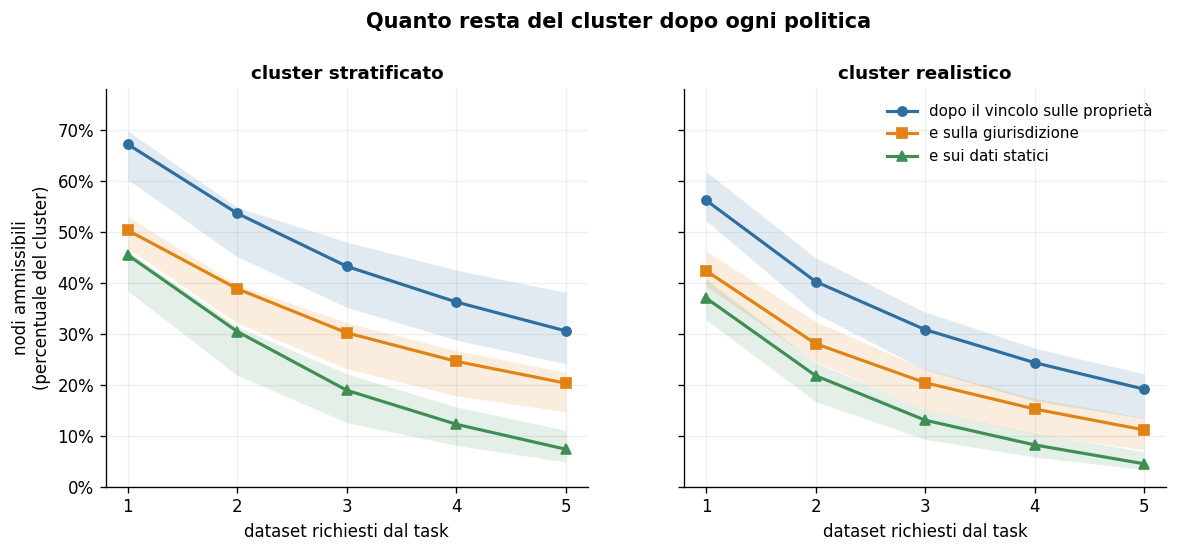

Frazione di nodi ammissibili dopo ciascuna politica, mediana su 10 semi

                                dopo proprietà  e giurisdizione  \
composizione dataset richiesti                                    
realistico   1                           0.562            0.424   
             2                           0.403            0.281   
             3                           0.308            0.204   
             4                           0.243            0.152   
             5                           0.191            0.111   
stratificato 1                           0.672            0.503   
             2                           0.536            0.388   
             3                           0.432            0.302   
             4                           0.362            0.246   
             5                           0.306            0.203   

                                e dati statici  
composizione dataset richiesti                  
realistico   1          

In [3]:
d = load("policy_funnel_tasks")
PREFISSO_MAX = int(d.n_datasets.max())

# A task that survives translation at the longest prefix survives at every
# shorter one, so restricting to these gives an identical sample at each
# request length.
superstiti = (d[(d.n_datasets == PREFISSO_MAX) & (~d.rifiutato_in_traduzione)]
              [["template", "seed", "task"]].drop_duplicates())
appaiato = d.merge(superstiti, on=["template", "seed", "task"])

ps = per_seme(appaiato, ["template", "n_datasets"], dict(
    prop=("frazione_prop", "mean"),
    geo=("frazione_geo", "mean"),
    static=("frazione_static", "mean"),
))

serie = [("prop", "dopo il vincolo sulle proprietà", BLU, "o"),
         ("geo", "e sulla giurisdizione", ARANCIO, "s"),
         ("static", "e sui dati statici", VERDE, "^")]

fig, assi = plt.subplots(1, 2, figsize=(11.4, 4.3), sharey=True)
for ax, template in zip(assi, TEMPLATE_ORDER):
    sub = ps[ps.template == template]
    for column, label, colour, marker in serie:
        curva(ax, sub, "n_datasets", column, colour, label, marker=marker)
    ax.set_title(f"cluster {TEMPLATE_NAMES[template]}")
    ax.set_xlabel("dataset richiesti dal task")
    ax.set_xticks(range(1, PREFISSO_MAX + 1))
    ax.set_ylim(0, 0.78)
    asse_percentuale(ax)
assi[0].set_ylabel("nodi ammissibili\n(percentuale del cluster)")
assi[1].legend(loc="upper right")
fig.suptitle("Quanto resta del cluster dopo ogni politica",
             y=1.03, fontsize=12.5, fontweight="semibold")
salva(fig, "imbuto_politiche")
plt.show()

tabella = ps.groupby(["template", "n_datasets"])[["prop", "geo", "static"]].median()
tabella.index = tabella.index.set_levels(
    [TEMPLATE_NAMES[t] for t in tabella.index.levels[0]], level=0)
tabella.index.names = ["composizione", "dataset richiesti"]
tabella.columns = ["dopo proprietà", "e giurisdizione", "e dati statici"]
print("Frazione di nodi ammissibili dopo ciascuna politica, mediana su 10 semi\n")
print(tabella.round(3))

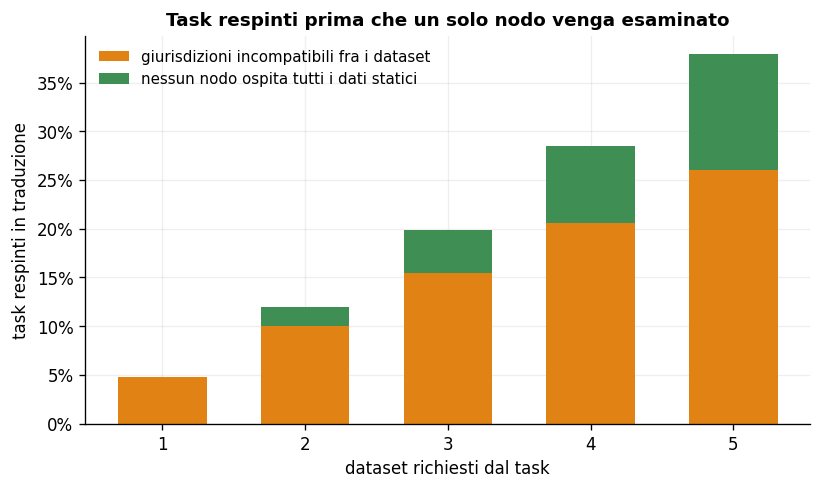

Rifiuti in traduzione, mediana su 10 semi

                   totale  per giurisdizione  per dati statici
dataset richiesti                                             
1                   0.048              0.048             0.000
2                   0.130              0.100             0.019
3                   0.225              0.155             0.044
4                   0.336              0.206             0.080
5                   0.432              0.260             0.119


In [4]:
mortalita = per_seme(d, ["n_datasets"], dict(
    totale=("rifiutato_in_traduzione", "mean"),
    giurisdizione=("causa_geo_empty", "mean"),
    dati_statici=("causa_static_empty", "mean"),
))

fig, ax = plt.subplots(figsize=(7.8, 4.2))
x = np.arange(1, PREFISSO_MAX + 1)
bottom = np.zeros(PREFISSO_MAX)
for column, label, colour in (
        ("giurisdizione", "giurisdizioni incompatibili fra i dataset", ARANCIO),
        ("dati_statici", "nessun nodo ospita tutti i dati statici", VERDE)):
    values = mortalita.groupby("n_datasets")[column].median().reindex(x).values
    ax.bar(x, values, 0.62, bottom=bottom, color=colour, label=label)
    bottom += values
ax.set_xlabel("dataset richiesti dal task")
ax.set_ylabel("task respinti in traduzione")
ax.set_xticks(x)
asse_percentuale(ax)
ax.legend(loc="upper left")
ax.set_title("Task respinti prima che un solo nodo venga esaminato")
salva(fig, "imbuto_mortalita")
plt.show()

tab = mortalita.groupby("n_datasets")[
    ["totale", "giurisdizione", "dati_statici"]].median()
tab.index.name = "dataset richiesti"
tab.columns = ["totale", "per giurisdizione", "per dati statici"]
print("Rifiuti in traduzione, mediana su 10 semi\n")
print(tab.round(3))

**Come leggere i grafici.** Nel primo, ciascun pannello corrisponde a una composizione
di cluster. Le tre curve sono cumulative: la prima riporta la frazione di nodi che
superano il vincolo sulle proprietà, la seconda quelli che superano anche il vincolo
geografico, la terza quelli che superano anche il vincolo sui dati statici. La
distanza verticale fra due curve consecutive è il contributo della singola politica.
La banda intorno a ciascuna curva copre lo scarto interquartile fra i semi.

Il secondo grafico riporta la quota di task che non raggiungono affatto la fase di
filtraggio, scomposta per causa. Le due quantità sono complementari: il primo grafico
descrive i task che restano in gioco, il secondo quelli che escono prima.

**Risultato.** Le curve sono monotone decrescenti in entrambe le composizioni, come la
struttura degli operatori impone. La monotonia vale esattamente task per task: sui
record appaiati non si registra alcuna violazione, e una violazione segnalerebbe un
errore di implementazione anziché un fenomeno.

Le due composizioni si comportano in modo qualitativamente identico e differiscono
solo per il livello. Il cluster stratificato lascia ammissibile una quota
sistematicamente maggiore di nodi già dopo il vincolo sulle proprietà, e conserva il
vantaggio lungo tutta la sequenza. La ragione è che, distribuendo le classi in modo
omogeneo sul reticolo, esso dispone di più nodi a ciascun livello, mentre il cluster
realistico concentra la propria capacità nella fascia bassa e i nodi che soddisfano i
requisiti più elevati vi risultano scarsi. Il divario non si allarga al crescere della
richiesta, il che indica che il vantaggio è una proprietà della composizione e non
della lunghezza della richiesta.

Il contributo delle tre politiche è chiaramente non uniforme. Il vincolo sulle
proprietà è quello che taglia di più in valore assoluto, e la sua incidenza cresce con
il numero di dataset perché il requisito effettivo si alza. Il vincolo geografico
sottrae una quota ulteriore sostanzialmente costante in proporzione. Il vincolo sui
dati statici incide in misura crescente, coerentemente con la probabilità che
l'intersezione dei nodi che ospitano i dati si riduca.

Il secondo grafico mostra un vincolo che l'imbuto da solo nasconderebbe: la quota di
task respinti in traduzione cresce da circa il cinque per cento con un solo dataset a
quasi metà del carico con cinque, e le due cause pesano diversamente, con la
giurisdizione dominante sulle richieste brevi e i dati statici in crescita più rapida
su quelle lunghe.

**Conclusione.** Il numero di dataset per task è una leva di dimensionamento tanto
quanto la composizione del cluster, e agisce su due fronti distinti: restringe il pool
per i task che restano ammissibili e rende inammissibile una quota crescente di
richieste. Poiché entrambi gli effetti discendono dalla definizione degli operatori
del modello, sono strutturali e non dipendono dalle distribuzioni adottate, le quali
ne determinano la pendenza ma non la direzione. In fase di progetto conviene limitare
l'aggregazione di sorgenti eterogenee in un singolo task, oppure accettare che tali
task dispongano di un insieme di collocazioni molto ristretto.

## Il costo di ciascuna proprietà aggiunta al modello

La sezione precedente misura il contributo delle politiche nella loro composizione. Le
due sezioni che seguono ne isolano una ciascuna, per misurarne la restrittività
intrinseca, indipendente dall'ordine di valutazione e dalle altre politiche.

**Che cosa si misura.** Il vincolo sulle proprietà richiede che il nodo domini il
requisito su ogni proprietà contemporaneamente. La sua restrittività dipende quindi
non solo dal livello richiesto, ma da quante proprietà il modello definisce. Si misura
la frazione di nodi che raggiungono un livello fissato su un numero crescente di
proprietà.

**Perché ci si attende un decadimento geometrico.** Se le proprietà sono estratte in
modo indipendente e una frazione $q$ dei nodi raggiunge il livello richiesto su una
singola proprietà, la frazione che lo raggiunge su $P$ proprietà è $q^P$. Nel cluster
stratificato, dove ogni componente è uniforme sui tre livelli, si ha $q = 2/3$ per il
livello due e $q = 1/3$ per il livello tre. Nel cluster realistico, dove i livelli
bassi sono più frequenti, $q$ vale rispettivamente un mezzo e un sesto. Il confronto
fra la forma chiusa e la misura verifica al tempo stesso l'implementazione e la
validità dell'ipotesi di indipendenza.

**Configurazione di partenza.** Cluster di trentasei nodi come nella configurazione di
riferimento, ma con cinque proprietà anziché tre, per disporre di un intervallo più
ampio su cui osservare il decadimento. Nessun dataset, nessuna giurisdizione, nessun
conflitto: la misura riguarda esclusivamente il vincolo sulle proprietà.

**Che cosa varia.** Il numero di proprietà considerate, da una a cinque, e il livello
richiesto su ciascuna, due o tre. Il livello uno è escluso perché ogni nodo lo soddisfa
per costruzione e la misura sarebbe priva di contenuto.

**Perché il requisito è fissato anziché estratto.** Estrarlo dai task avrebbe mescolato
la dimensionalità del reticolo con l'amplificazione del requisito effettivo sui dataset
richiesti, che è precisamente ciò che l'esperimento sull'imbuto già misura.

**Disegno appaiato per proiezione.** Il cluster è generato una volta sola con cinque
proprietà, e il cluster a $P$ proprietà si ottiene osservando gli stessi nodi su un
sottoinsieme delle loro componenti. Il cluster a due proprietà è quindi letteralmente
quello a cinque, guardato su due coordinate. La monotonia diventa esatta per
costruzione, poiché un nodo che domina il requisito su $P+1$ componenti lo domina
necessariamente su $P$ di esse.

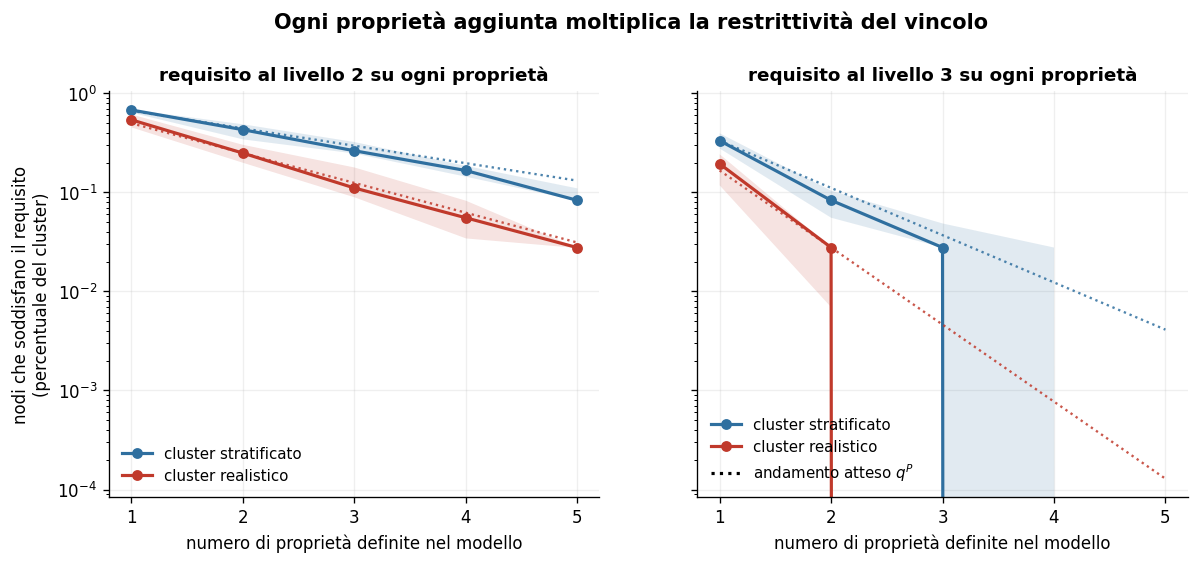

Frazione di nodi che soddisfano il requisito, mediana su 10 semi

proprietà                            1       2       3       4       5
livello richiesto composizione                                        
2                 realistico    0.5417  0.2500  0.1111  0.0556  0.0278
                  stratificato  0.6806  0.4306  0.2639  0.1667  0.0833
3                 realistico    0.1944  0.0278  0.0000  0.0000  0.0000
                  stratificato  0.3333  0.0833  0.0278  0.0000  0.0000


In [5]:
d = load("property_dimensionality_tasks")
d["frazione"] = d.n_admissible / d.n_nodes

ps = per_seme(d, ["template", "n_properties", "required_level"],
              dict(frazione=("frazione", "mean")))

P_MAX = int(d.n_properties.max())
x_teorico = np.arange(1, P_MAX + 1)

# Closed form under independence: q is the share of nodes reaching the
# required level on a single property, so q ** P on P properties.
ATTESE = {
    ("stratified", 2): 2 / 3, ("stratified", 3): 1 / 3,
    ("realistic", 2): 1 / 2, ("realistic", 3): 1 / 6,
}

fig, assi = plt.subplots(1, 2, figsize=(11.6, 4.4), sharey=True)
for ax, level in zip(assi, sorted(d.required_level.unique())):
    for template in TEMPLATE_ORDER:
        sub = ps[(ps.template == template) & (ps.required_level == level)]
        curva(ax, sub, "n_properties", "frazione", TEMPLATE_COLOURS[template],
              f"cluster {TEMPLATE_NAMES[template]}")
        q = ATTESE[(template, level)]
        ax.plot(x_teorico, q ** x_teorico, ":",
                color=TEMPLATE_COLOURS[template], linewidth=1.4, alpha=0.85)
    ax.set_xlabel("numero di proprietà definite nel modello")
    ax.set_xticks(x_teorico)
    ax.set_yscale("log")
    ax.set_title(f"requisito al livello {level} su ogni proprietà")
assi[0].set_ylabel("nodi che soddisfano il requisito\n(percentuale del cluster)")
assi[0].legend(loc="lower left")
assi[1].plot([], [], ":", color="black", label="andamento atteso $q^P$")
assi[1].legend(loc="lower left")
fig.suptitle("Ogni proprietà aggiunta moltiplica la restrittività del vincolo",
             y=1.03, fontsize=12.5, fontweight="semibold")
salva(fig, "proprieta_dimensionalita")
plt.show()

tab = ps.groupby(["required_level", "template", "n_properties"]).frazione.median()
tab = tab.unstack("n_properties")
tab.index = tab.index.set_levels(
    [TEMPLATE_NAMES[t] for t in tab.index.levels[1]], level=1)
tab.index.names = ["livello richiesto", "composizione"]
tab.columns.name = "proprietà"
print("Frazione di nodi che soddisfano il requisito, mediana su 10 semi\n")
print(tab.round(4))

**Come leggere il grafico.** I due pannelli corrispondono ai due livelli di requisito.
Le curve continue riportano la misura, quelle punteggiate l'andamento atteso sotto
ipotesi di indipendenza fra le proprietà. L'asse verticale è in scala logaritmica: un
decadimento geometrico vi appare come una retta, ed è il modo più diretto per
verificare la forma dell'andamento.

**Risultato.** Le curve misurate seguono l'andamento atteso e sulla scala logaritmica
appaiono rettilinee, il che conferma sia il decadimento geometrico sia la validità
dell'ipotesi di indipendenza fra le proprietà.

L'effetto è considerevole. Con requisito al livello due, ogni proprietà aggiunta
dimezza all'incirca i nodi ammissibili nel cluster realistico e li riduce di un terzo
in quello stratificato: passando da una a cinque proprietà si scende da circa il
cinquantaquattro al tre per cento nel primo caso, e dal sessantotto al nove per cento
nel secondo. Con requisito al livello tre il decadimento è molto più rapido, e già a
quattro proprietà nessun nodo del cluster realistico soddisfa il requisito.

**Conclusione.** Il costo di una proprietà aggiunta al modello è moltiplicativo e non
additivo. È una indicazione di progetto diretta: le proprietà astratte vanno
introdotte solo quando esprimono un requisito realmente distinto, perché ciascuna
riduce l'ammissibilità di un fattore pari alla quota di nodi che raggiungono il
livello richiesto su quella proprietà.

Vale l'osservazione simmetrica sul numero di livelli. Nel cluster stratificato il
fattore per proprietà vale $(L - \ell + 1)/L$ per un requisito al livello $\ell$ su
$L$ livelli disponibili, quindi aumentare il numero di livelli a parità di requisito
allarga l'ammissibilità. Proprietà e livelli agiscono in direzioni opposte, e un
modello con molte proprietà a pochi livelli risulta più restrittivo di uno con poche
proprietà a molti livelli.

## Residenza dei dati statici e fattore di replica

**Che cosa si misura.** I dataset marcati come statici non possono essere trasferiti:
il task deve raggiungerli dove si trovano. Quando un task ne richiede più d'uno, i nodi
candidati sono quelli che li ospitano tutti localmente, ovvero l'intersezione degli
insiemi dei nodi che ne detengono una copia. Se l'intersezione è vuota il task viene
respinto in traduzione. Si misura la frequenza di questo rifiuto e l'effetto
complessivo sulla quota di task che trovano una collocazione.

**Perché ci si attende un andamento non lineare.** Se ciascun dataset risiede su $r$
nodi di un template di $M$, e i piazzamenti sono indipendenti, l'intersezione di $k$
dataset statici ha dimensione attesa $M (r/M)^k$. La probabilità che sia vuota cresce
quindi rapidamente con il numero di dataset statici combinati, e si riduce con $r$ in
modo più che lineare. Il fattore di replica va perciò dimensionato in rapporto al
numero di dataset statici che un task tipicamente combina, e non alla dimensione del
cluster.

**Configurazione di partenza.** Configurazione di riferimento, cluster realistico di
trentasei nodi, richieste da uno a tre dataset, nessun conflitto poiché il cluster è
pulito.

**Che cosa varia.** Due parametri su una griglia completa. La frazione di dataset
statici nella popolazione, da zero a uno, che determina quanto spesso il vincolo si
applichi. Il numero di nodi su cui ciascun dataset risiede, da uno a cinque, che
determina quanto sia probabile l'esistenza di una intersezione non vuota.

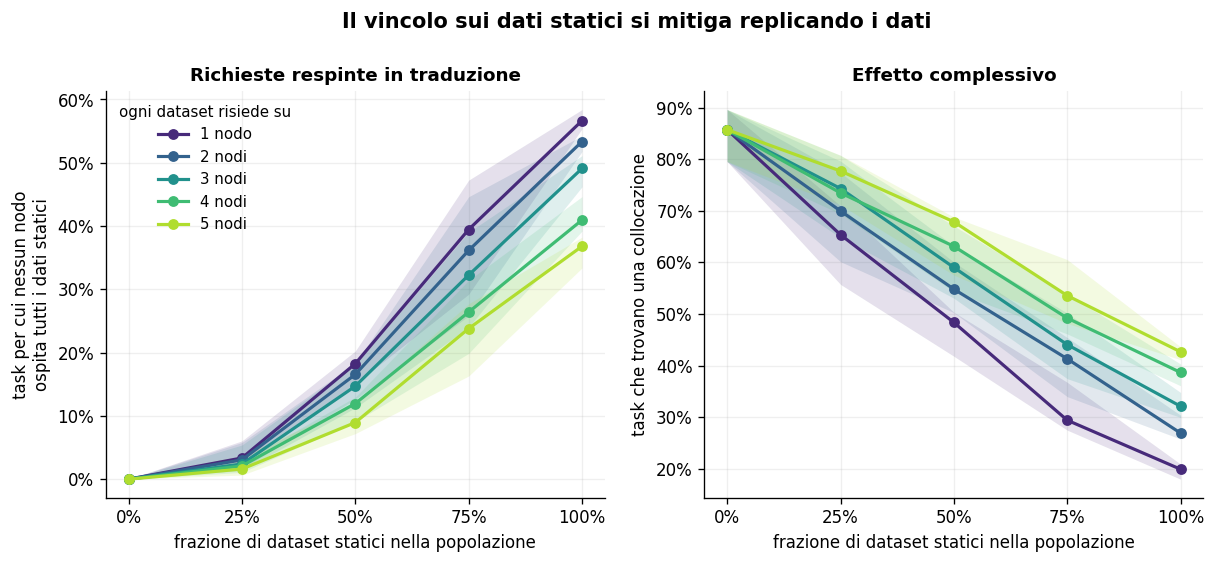

Richieste respinte per intersezione vuota, mediana su 10 semi

nodi per dataset      1      2      3      4      5
frazione statici                                   
0.00              0.000  0.000  0.000  0.000  0.000
0.25              0.034  0.030  0.024  0.021  0.016
0.50              0.182  0.165  0.147  0.120  0.090
0.75              0.394  0.362  0.322  0.264  0.238
1.00              0.566  0.534  0.491  0.410  0.368


In [6]:
d = load("static_data_tasks")
ps = per_seme(d, ["static_fraction", "data_replication"], dict(
    intersezione_vuota=("causa_static_empty", "mean"),
    assegnati=("assigned", "mean"),
))

repliche = sorted(ps.data_replication.unique())
colori = plt.cm.viridis(np.linspace(0.12, 0.88, len(repliche)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 4.4))
for colour, replica in zip(colori, repliche):
    sub = ps[ps.data_replication == replica]
    label = f"{replica} nod{'o' if replica == 1 else 'i'}"
    curva(ax1, sub, "static_fraction", "intersezione_vuota", colour, label)
    curva(ax2, sub, "static_fraction", "assegnati", colour, label)

ax1.set_title("Richieste respinte in traduzione")
ax1.set_ylabel("task per cui nessun nodo\nospita tutti i dati statici")
ax2.set_title("Effetto complessivo")
ax2.set_ylabel("task che trovano una collocazione")
for ax in (ax1, ax2):
    ax.set_xlabel("frazione di dataset statici nella popolazione")
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    asse_percentuale(ax)
    asse_percentuale(ax, axis="x")
ax1.legend(title="ogni dataset risiede su", title_fontsize=9)
fig.suptitle("Il vincolo sui dati statici si mitiga replicando i dati",
             y=1.03, fontsize=12.5, fontweight="semibold")
salva(fig, "dati_statici")
plt.show()

tab = ps.groupby(["static_fraction", "data_replication"]).intersezione_vuota.median()
tab = tab.unstack("data_replication")
tab.index.name = "frazione statici"
tab.columns.name = "nodi per dataset"
print("Richieste respinte per intersezione vuota, mediana su 10 semi\n")
print(tab.round(3))

**Come leggere il grafico.** A sinistra la frequenza del rifiuto in traduzione, a
destra la quota complessiva di task che trovano una collocazione. Ogni curva
corrisponde a un fattore di replica dei dati. Nel pannello di sinistra le curve più
basse indicano una configurazione migliore, in quello di destra le più alte.

**Risultato.** Il rifiuto per intersezione vuota cresce rapidamente con la quota di
dataset statici: con un quarto della popolazione statica riguarda pochi punti
percentuali dei task, con metà supera il quindici per cento e con la totalità arriva a
respingere oltre metà del carico.

La replica dei dati attenua il fenomeno in modo sistematico ma con rendimenti
crescenti solo lentamente. Nel caso più severo, con tutti i dataset statici, passare
da una a due copie riduce i rifiuti di appena tre punti percentuali, mentre da una a
cinque copie li riduce di venti punti. Il guadagno per copia aggiunta cresce con il
numero di copie già presenti, il che è coerente con il carattere combinatorio del
fenomeno: finché il numero di copie resta piccolo rispetto al numero di dataset
statici da intersecare, l'intersezione resta quasi sempre vuota.

**Conclusione.** Una replica minimale dei dati statici non è sufficiente, e il
beneficio di ciascuna copia aggiuntiva si manifesta solo oltre una certa soglia. Il
fattore di replica va dimensionato in rapporto al numero tipico di dataset statici che
un singolo task combina, non in rapporto alla dimensione del cluster. È un vincolo che
riguarda lo strato di memorizzazione dei dati e non quello di calcolo, e la sezione
successiva mostra che i due non sono intercambiabili.

## Perché il vincolo geografico non ha una sezione dedicata

Le due politiche precedenti sono state isolate perché la loro restrittività intrinseca
dipende da un parametro proprio e non banale: il numero di proprietà per la prima, il
fattore di replica dei dati per la seconda. Il vincolo geografico non è stato isolato
allo stesso modo, per una ragione che vale la pena esplicitare.

Preso da solo, il vincolo geografico ammette i nodi la cui località appartiene alla
giurisdizione effettiva. La frazione ammissibile è quindi, per definizione, la quota di
nodi collocati in tale giurisdizione. Poiché nella configurazione di riferimento i nodi
sono distribuiti uniformemente sulle località, tale quota vale esattamente il rapporto
fra il numero di località ammesse e il numero totale di località. La misura
restituirebbe una identità, non un risultato.

Il vincolo geografico diventerebbe interessante solo in presenza di uno sbilanciamento
fra la distribuzione geografica della capacità di calcolo e quella dei vincoli
giurisdizionali, ovvero quando la maggior parte dei nodi si trova in una regione mentre
i dati devono restare in un'altra. Misurarlo richiederebbe di introdurre nel generatore
un parametro di concentrazione geografica dei nodi che il modello non prevede e che il
prototipo non espone, e che descriverebbe una proprietà dell'infrastruttura anziché del
modello.

Il contributo del vincolo geografico resta comunque misurato in due punti. Nella
sezione sull'imbuto compare come distanza fra la prima e la seconda curva, ovvero come
contributo marginale dato l'ordine di valutazione. Nella sezione sui rifiuti in
traduzione compare come frequenza con cui la giurisdizione effettiva risulta vuota, che
è il modo in cui il vincolo si manifesta nella forma più severa: non escludendo alcuni
nodi, ma rendendo la richiesta irrealizzabile ovunque.

Questo secondo effetto merita una precisazione, perché è quello che più facilmente
viene attribuito a una configurazione insufficiente del cluster. Il rifiuto per
giurisdizioni incompatibili avviene in traduzione e non dipende in alcun modo dal
numero di nodi disponibili. Dipende invece dal panorama giurisdizionale, ovvero da
quante giurisdizioni distinte esistano e da quanti dataset siano vincolati a una
specifica anziché a un gruppo ampio. Una organizzazione che opera in una sola
giurisdizione non incontra mai il fenomeno; una che opera su molte lo incontra in
misura crescente. Non si tratta di una limitazione del sistema ma del suo
funzionamento corretto: un task che combina dati soggetti a giurisdizioni incompatibili
non è eseguibile in alcun luogo, e il modello lo respinge in traduzione anziché
produrre una assegnazione che violerebbe un vincolo di sovranità dei dati.

## L'effetto dell'ingrandimento del cluster

**Che cosa si misura.** Aggiungere nodi è la risposta istintiva a un sistema che
respinge troppi task. Si verifica per quali politiche produca effettivamente un
beneficio, misurando sia il numero assoluto di nodi ammissibili sia la loro frazione
sul totale. Osservare entrambi è essenziale, perché una frazione costante e un numero
assoluto costante hanno significati opposti: nel primo caso il pool cresce insieme al
cluster, nel secondo non cresce affatto.

**Configurazione di partenza.** Configurazione di riferimento, cluster realistico,
richieste da uno a tre dataset, un quarto dei quali statici, ciascuno su tre nodi del
template. Il cluster è pulito e non vi sono conflitti.

**Che cosa varia.** Il fattore di replica del cluster, da uno a otto, che porta la
dimensione da trentasei a duecentottantotto nodi, nelle due modalità di replica dei
dati. I risultati sono separati fra i task che richiedono almeno un dataset statico e
quelli che non ne richiedono alcuno, poiché solo i primi sono vincolati alla posizione
dei dati: un dataset non statico è trasferibile, e la posizione delle sue copie
influenza il volume di dati che attraversa la rete ma non l'ammissibilità del nodo.

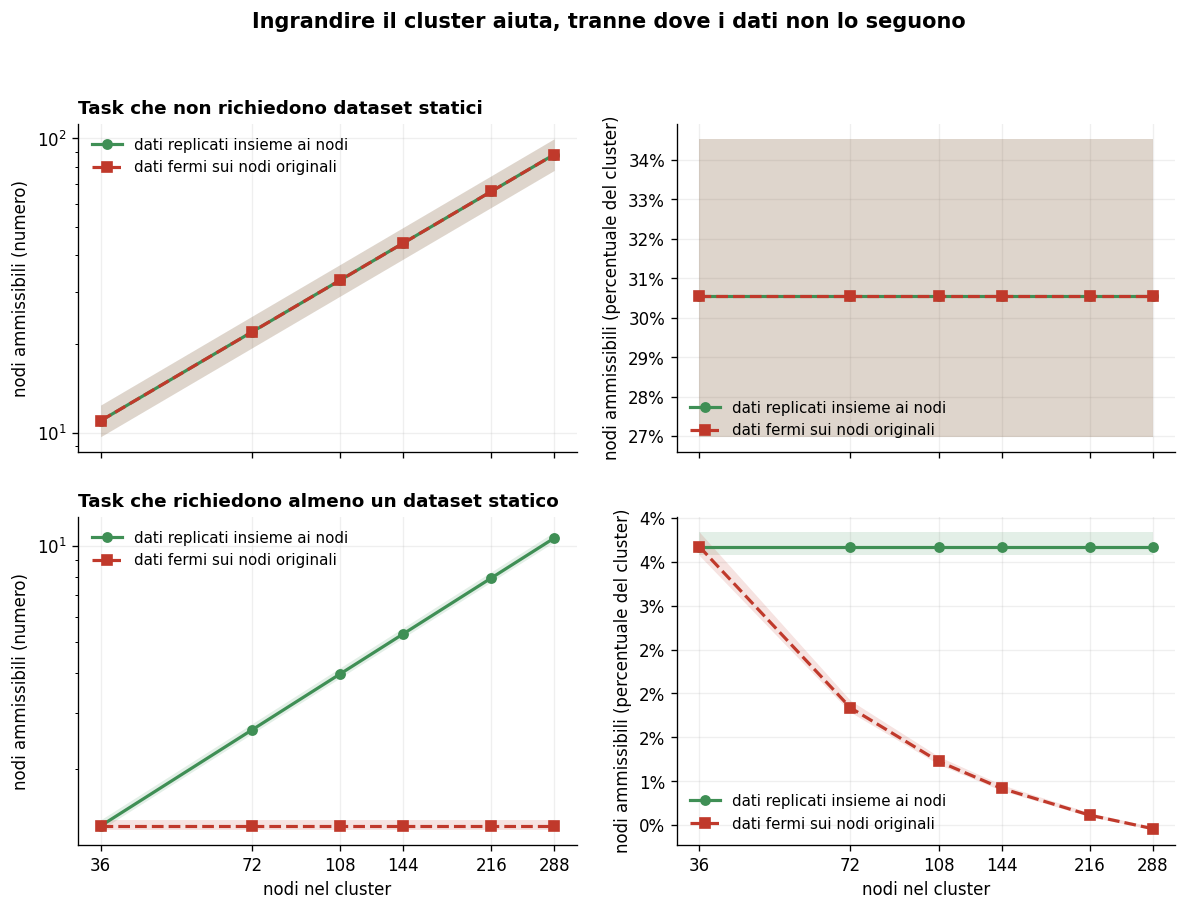

Nodi ammissibili al crescere del cluster, mediana su 10 semi

                                                    nodi nel cluster  \
richiede statici dati replicati fattore di replica                     
False            False          1                               36.0   
                                2                               72.0   
                                3                              108.0   
                                4                              144.0   
                                6                              216.0   
                                8                              288.0   
                 True           1                               36.0   
                                2                               72.0   
                                3                              108.0   
                                4                              144.0   
                                6                              216.0   
  

In [7]:
d = load("scale_tasks")
d = d[~d.rifiutato_in_traduzione]

ps = per_seme(d, ["data_follows_nodes", "richiede_statici", "replication_factor"],
              dict(assoluti=("n_admissible", "mean"),
                   frazione=("frazione_ammissibili", "mean"),
                   nodi=("n_nodes", "mean")))

fattori = sorted(ps.replication_factor.unique())
NODI_TEMPLATE = int(ps.nodi.min())
etichette_x = [str(NODI_TEMPLATE * f) for f in fattori]

righe = [(False, "Task che non richiedono dataset statici"),
         (True, "Task che richiedono almeno un dataset statico")]
colonne = [("assoluti", "nodi ammissibili (numero)"),
           ("frazione", "nodi ammissibili (percentuale del cluster)")]
modalita = [(True, "dati replicati insieme ai nodi", VERDE, "-", "o"),
            (False, "dati fermi sui nodi originali", ROSSO, "--", "s")]

fig, assi = plt.subplots(2, 2, figsize=(11.8, 7.8), sharex=True)
for i, (statici, titolo) in enumerate(righe):
    for j, (metrica, etichetta) in enumerate(colonne):
        ax = assi[i][j]
        for segue, label, colour, style, marker in modalita:
            sub = ps[(ps.data_follows_nodes == segue)
                     & (ps.richiede_statici == statici)]
            if sub.empty:
                continue
            curva(ax, sub, "replication_factor", metrica, colour, label,
                  marker=marker, style=style)
        ax.set_xscale("log", base=2)
        ax.set_xticks(fattori)
        ax.set_xticklabels(etichette_x)
        ax.set_ylabel(etichetta)
        if j == 0:
            ax.set_title(titolo, loc="left")
            ax.set_yscale("log")
        else:
            asse_percentuale(ax)
        ax.legend(loc="best")
for ax in assi[1]:
    ax.set_xlabel("nodi nel cluster")
fig.suptitle("Ingrandire il cluster aiuta, tranne dove i dati non lo seguono",
             y=1.0, fontsize=12.5, fontweight="semibold")
salva(fig, "scala_cluster")
plt.show()

tab = (ps.groupby(["richiede_statici", "data_follows_nodes", "replication_factor"])
       [["nodi", "assoluti", "frazione"]].median())
tab.index.names = ["richiede statici", "dati replicati", "fattore di replica"]
tab.columns = ["nodi nel cluster", "nodi ammissibili", "frazione ammissibile"]
print("Nodi ammissibili al crescere del cluster, mediana su 10 semi\n")
print(tab.round(3))

**Come leggere il grafico.** La riga superiore riguarda i task che non richiedono
dataset statici, quella inferiore i task che ne richiedono almeno uno. La colonna di
sinistra riporta il numero assoluto di nodi ammissibili in scala logaritmica, quella di
destra la stessa quantità espressa come percentuale del cluster. Le curve continue
corrispondono alla modalità in cui i dati seguono i nodi, quelle tratteggiate alla
modalità in cui restano fermi.

**Risultato.** Per i task che non richiedono dataset statici le due modalità
coincidono, poiché un dataset trasferibile può essere raggiunto ovunque. Il numero di
nodi ammissibili cresce proporzionalmente alla dimensione del cluster e la frazione
resta costante: il vincolo sulle proprietà e quello geografico sono invarianti alla
scala, perché replicare il template replica anche i nodi di ogni classe e di ogni
località.

Per i task che richiedono dataset statici il comportamento dipende interamente da dove
risiedono i dati. Se i dati seguono i nodi, il pool cresce insieme al cluster e la
frazione resta stabile. Se i dati restano fermi, il numero assoluto di nodi
ammissibili non cresce al crescere del cluster, e la frazione collassa verso lo zero.

**Conclusione.** È il risultato più rilevante della Parte I, e contraddice
l'intuizione: la scalabilità orizzontale non produce alcun beneficio per i task
vincolati a dati statici, a meno che non si replichino anche i dati. Aggiungere nodi di
calcolo senza intervenire sullo strato di memorizzazione lascia questi task esattamente
nella condizione di partenza. La stessa dinamica si ripresenta nella Parte II, dove la
ridondanza dei nodi viene valutata come mitigazione contro il blocco da conflitto di
interesse.

# Parte II. La dinamica dell'assegnazione

Nella Parte I il cluster era pulito e ogni task veniva valutato in isolamento. Qui il
carico viene eseguito come sequenza ordinata: ogni task assegnato deposita sul nodo che
lo esegue l'insieme dei contesti a cui ha avuto accesso, e quel deposito vincola i task
successivi attraverso la politica di Chinese Wall.

L'unica variabile di stato che vincola l'assegnazione è l'impronta contestuale del
nodo. È una quantità monotona crescente, che si azzera soltanto quando il nodo viene
sanificato. In assenza di sanificazione i nodi accumulano tracce indefinitamente, e la
probabilità che un nuovo task trovi un conflitto cresce fino a stabilizzarsi su un
valore elevato. È questa monotonia a rendere la politica di Chinese Wall l'unico punto
del modello che può degradare progressivamente.

**Un chiarimento su ciò che non viene modellato.** L'implementazione tiene traccia dei
task in esecuzione su ciascun nodo, ma non impone alcun limite al loro numero: un nodo
non viene mai escluso perché già occupato. Il conteggio dei task attivi serve a un
unico scopo, ovvero riprodurre il comportamento della sanificazione, che nel prototipo
attende il completamento dei task in corso sul nodo prima di azzerarne l'impronta. La
saturazione dei nodi per esaurimento di risorse di calcolo non fa parte del modello e
non è valutata qui: in Kubernetes è gestita da meccanismi nativi esterni al contributo
di questa tesi. I risultati che seguono vanno letti tenendo presente che in un cluster
realmente carico una quota ulteriore di task non troverebbe collocazione per ragioni
indipendenti dalle politiche.

## Conflitti di interesse e schedulabilità

**Che cosa si misura.** La frazione di task bloccati dallo stato al crescere della
competizione fra i soggetti che utilizzano il cluster.

**Configurazione di partenza.** Configurazione di riferimento: cluster realistico di
trentasei nodi, trenta contesti, un soggetto per contesto, richieste da uno a tre
dataset, duemila task per esecuzione. La sanificazione è quella periodica con periodo
pari a cinquanta passi.

**Che cosa varia.** La densità dei conflitti, da zero a 0.5. L'estremo inferiore
descrive un cluster in cui nessun soggetto è in conflitto con altri, e serve a misurare
il costo residuo della sola sanificazione. L'estremo superiore descrive uno scenario di
competizione molto intensa, in cui metà delle coppie di contesti sono incompatibili.
L'intervallo è campionato più fittamente nella parte bassa, dove la curva presenta
maggiore curvatura.

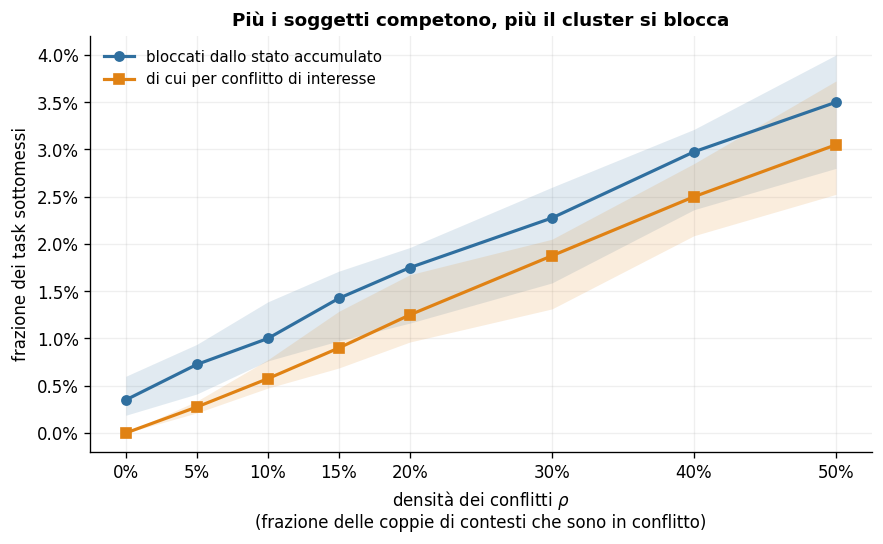

Effetto della densità dei conflitti, mediana su 10 semi

                   bloccati dallo stato  per conflitto  assegnati
densità conflitti                                                
0.00                             0.0035         0.0000     0.7372
0.05                             0.0072         0.0028     0.7355
0.10                             0.0100         0.0058     0.7320
0.15                             0.0142         0.0090     0.7285
0.20                             0.0175         0.0125     0.7255
0.30                             0.0228         0.0188     0.7190
0.40                             0.0298         0.0250     0.7108
0.50                             0.0350         0.0305     0.7030


In [8]:
d = load("conflicts_tasks")
ps = per_seme(d, ["conflict_density"], dict(
    bloccati=("blocked_by_state", "mean"),
    per_conflitto=("causa_wall", "mean"),
    assegnati=("assigned", "mean"),
))

fig, ax = plt.subplots(figsize=(8.4, 4.5))
curva(ax, ps, "conflict_density", "bloccati", BLU,
      "bloccati dallo stato accumulato")
curva(ax, ps, "conflict_density", "per_conflitto", ARANCIO,
      "di cui per conflitto di interesse", marker="s")
ax.set_xlabel("densità dei conflitti $\\rho$\n"
              "(frazione delle coppie di contesti che sono in conflitto)")
ax.set_ylabel("frazione dei task sottomessi")
ax.set_xticks(sorted(ps.conflict_density.unique()))
asse_percentuale(ax, decimals=1)
asse_percentuale(ax, axis="x")
ax.legend(loc="upper left")
ax.set_title("Più i soggetti competono, più il cluster si blocca")
salva(fig, "conflitti")
plt.show()

tab = ps.groupby("conflict_density")[
    ["bloccati", "per_conflitto", "assegnati"]].median()
tab.index.name = "densità conflitti"
tab.columns = ["bloccati dallo stato", "per conflitto", "assegnati"]
print("Effetto della densità dei conflitti, mediana su 10 semi\n")
print(tab.round(4))

**Come leggere il grafico.** La curva superiore riporta tutti i task che non trovano un
nodo per effetto dello stato accumulato. La curva inferiore riporta il sottoinsieme in
cui è la politica di Chinese Wall a esaurire il pool. La differenza fra le due è dovuta
ai nodi temporaneamente sottratti perché in sanificazione, che bloccano task pur senza
che vi sia alcun conflitto.

**Risultato.** Il blocco cresce con la densità dei conflitti in modo regolare e
sublineare, passando da circa mezzo punto percentuale in assenza di conflitti a poco
più di tre punti nello scenario più competitivo. La crescita non è proporzionale alla
densità perché la sanificazione periodica interviene a ripulire i nodi prima che la
contaminazione diventi generalizzata.

Il valore residuo in assenza totale di conflitti non è rumore. Con densità nulla la
politica di Chinese Wall non esclude mai alcun nodo, e infatti la curva inferiore parte
esattamente da zero. Il valore non nullo della curva superiore è interamente il costo
della sanificazione, che sottrae temporaneamente nodi all'insieme disponibile. La
sezione successiva quantifica quel costo e mostra come dipenda dal periodo scelto.

**Conclusione.** Il meccanismo di isolamento degrada in modo prevedibile e non
catastrofico: anche in scenari di competizione intensa la quota di task bloccati resta
contenuta, a condizione che la sanificazione sia attiva e correttamente dimensionata.
La densità dei conflitti è una caratteristica dell'ambiente e non un parametro di
progetto, quindi il margine di intervento risiede interamente nella configurazione
della sanificazione e nella ridondanza del cluster, oggetto delle due sezioni seguenti.

## Il periodo di sanificazione e il compromesso che comporta

**Che cosa si misura.** La sanificazione è il meccanismo che limita la crescita
dell'impronta contestuale, e senza di esso il cluster si contamina progressivamente.
Comporta però un costo: un nodo in sanificazione è temporaneamente escluso dall'insieme
dei nodi disponibili, e resta tale finché i task che stava eseguendo non terminano. Si
misurano quindi due grandezze congiuntamente, la frazione di task bloccati e la
frazione media di nodi sottratti all'insieme disponibile.

**Perché ci si attende un compromesso.** Con un periodo lungo l'impronta contestuale ha
il tempo di saturare fra un intervento e il successivo, e i blocchi per conflitto
aumentano. Con un periodo breve i nodi trascorrono una quota crescente del tempo fuori
dall'insieme disponibile, e i blocchi aumentano di nuovo, per la ragione opposta. Fra i
due regimi deve quindi esistere un valore ottimale.

**Configurazione di partenza.** Configurazione di riferimento, cluster realistico di
trentasei nodi, duemila task per esecuzione, durata dei task pari a dieci passi.

**Che cosa varia.** Il periodo, da due a trecento passi, su dieci valori spaziati in
modo approssimativamente logaritmico. L'intervallo parte da valori molto bassi perché
il ramo del compromesso in cui la sanificazione è troppo frequente si manifesta solo per
periodi confrontabili con la durata dei task, e arriva a valori molto alti perché il
ramo opposto emerge solo quando l'impronta ha il tempo di saturare. L'esperimento è
ripetuto per tre livelli di densità dei conflitti, per verificare se la posizione
dell'ottimo dipenda dall'intensità della competizione.

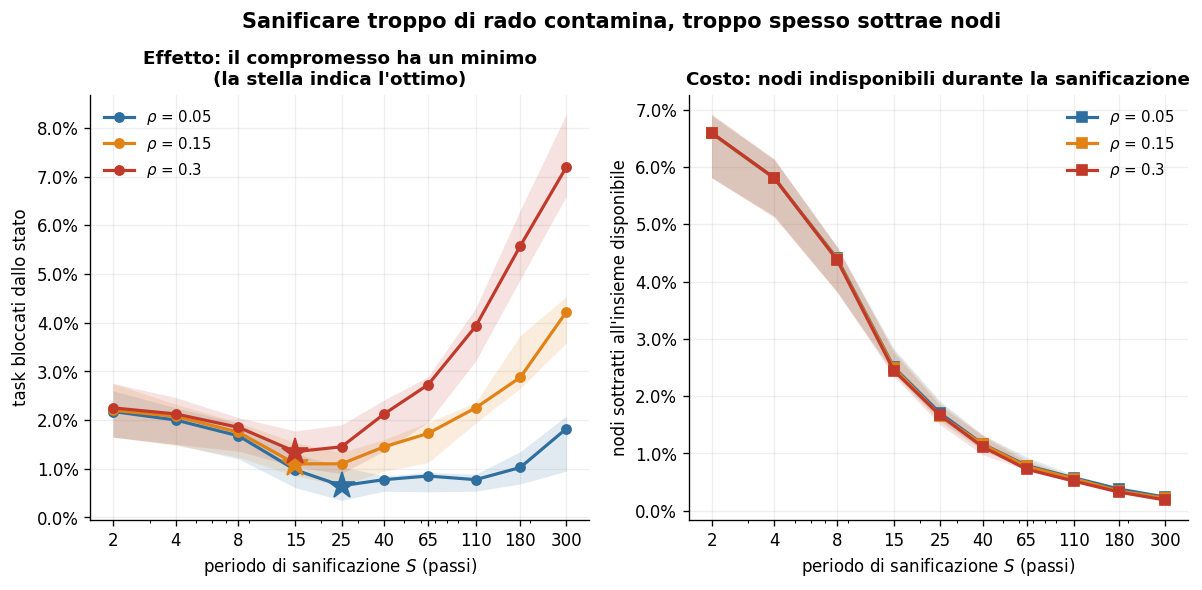

Task bloccati per periodo di sanificazione, mediana su 10 semi

densità conflitti    0.05    0.15    0.30
periodo S                                
2                  0.0217  0.0220  0.0225
4                  0.0200  0.0207  0.0212
8                  0.0168  0.0175  0.0185
15                 0.0098  0.0110  0.0135
25                 0.0065  0.0110  0.0145
40                 0.0078  0.0145  0.0212
65                 0.0085  0.0173  0.0272
110                0.0078  0.0225  0.0392
180                0.0102  0.0288  0.0557
300                0.0183  0.0422  0.0720

Periodo ottimale per ciascuna densità dei conflitti:
  rho = 0.05: S = 25, con 0.65% di task bloccati
  rho = 0.15: S = 15, con 1.10% di task bloccati
  rho = 0.3: S = 15, con 1.35% di task bloccati


In [9]:
d = load("sanitization_tasks")
steps = load("sanitization_steps")
N_NODI = int(d.n_nodes.iloc[0])

periodica = d[d.strategy == "periodic"]
ps_bloc = per_seme(periodica, ["period", "conflict_density"],
                   dict(bloccati=("blocked_by_state", "mean")))
ps_disp = per_seme(steps[steps.strategy == "periodic"],
                   ["period", "conflict_density"],
                   dict(disponibili=("n_available", "mean")))
ps_disp["sottratti"] = 1 - ps_disp.disponibili / N_NODI

densita = sorted(ps_bloc.conflict_density.unique())
colori = [BLU, ARANCIO, ROSSO]
periodi = sorted(ps_bloc.period.unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 4.6))
for colour, rho in zip(colori, densita):
    sub = ps_bloc[ps_bloc.conflict_density == rho]
    b = curva(ax1, sub, "period", "bloccati", colour, f"$\\rho$ = {rho}")
    ottimo = b.loc[b.mediana.idxmin()]
    ax1.plot(ottimo.period, ottimo.mediana, "*", color=colour, markersize=17,
             zorder=5)
    sub2 = ps_disp[ps_disp.conflict_density == rho]
    curva(ax2, sub2, "period", "sottratti", colour, f"$\\rho$ = {rho}", marker="s")

for ax in (ax1, ax2):
    ax.set_xscale("log")
    ax.set_xticks(periodi)
    ax.set_xticklabels(periodi)
    ax.set_xlabel("periodo di sanificazione $S$ (passi)")
    ax.legend(loc="best")
asse_percentuale(ax1, decimals=1)
asse_percentuale(ax2, decimals=1)
ax1.set_ylabel("task bloccati dallo stato")
ax2.set_ylabel("nodi sottratti all'insieme disponibile")
ax1.set_title("Effetto: il compromesso ha un minimo\n(la stella indica l'ottimo)")
ax2.set_title("Costo: nodi indisponibili durante la sanificazione")
fig.suptitle("Sanificare troppo di rado contamina, troppo spesso sottrae nodi",
             y=1.03, fontsize=12.5, fontweight="semibold")
salva(fig, "sanificazione_periodo")
plt.show()

tab = ps_bloc.groupby(["conflict_density", "period"]).bloccati.median().unstack(0)
tab.index.name = "periodo S"
tab.columns.name = "densità conflitti"
print("Task bloccati per periodo di sanificazione, mediana su 10 semi\n")
print(tab.round(4))
print("\nPeriodo ottimale per ciascuna densità dei conflitti:")
for rho in densita:
    s = ps_bloc[ps_bloc.conflict_density == rho].groupby("period").bloccati.median()
    print(f"  rho = {rho}: S = {int(s.idxmin())}, con {s.min():.2%} di task bloccati")

**Come leggere il grafico.** Nel pannello di sinistra la frazione di task bloccati in
funzione del periodo, con una curva per livello di densità dei conflitti; la stella
segna il minimo di ciascuna curva. Nel pannello di destra il costo del meccanismo,
ovvero la frazione media di nodi sottratti all'insieme disponibile. L'asse orizzontale è
logaritmico in entrambi i pannelli.

**Risultato.** Il compromesso atteso si manifesta chiaramente e la curva assume la
forma attesa. A destra del minimo i blocchi crescono perché l'impronta contestuale
satura fra un intervento e il successivo. A sinistra crescono perché la sanificazione
stessa sottrae nodi, come conferma il pannello di destra, dove la quota di nodi
indisponibili aumenta ripidamente al ridursi del periodo e diventa il fattore dominante
per periodi confrontabili con la durata dei task.

La posizione dell'ottimo si sposta verso periodi più brevi al crescere della densità
dei conflitti. La ragione è che una maggiore competizione rende più costoso lasciare le
tracce sui nodi, quindi conviene spostare il punto di equilibrio verso una
sanificazione più frequente, accettando una indisponibilità maggiore. Il valore che la
curva assume nel minimo cresce anch'esso con la densità, poiché nessuna scelta del
periodo può eliminare del tutto il conflitto.

Il ramo sinistro del compromesso è visibile solo perché l'esplorazione parte da periodi
molto brevi. Limitandosi a periodi superiori alla durata dei task la curva sarebbe
apparsa monotona crescente, e il compromesso sarebbe rimasto invisibile.

**Conclusione.** Il periodo di sanificazione è un parametro da calibrare e non da
scegliere arbitrariamente, e l'ottimo non si trova agli estremi dell'intervallo. Il
valore va rapportato sia alla durata dei task, poiché la sanificazione deve attenderne
il completamento, sia alla densità dei conflitti attesa nell'ambiente, poiché è questa a
determinare quanto costi lasciare tracce sui nodi. Un sistema in cui la competizione fra
i soggetti è intensa richiede una sanificazione più frequente di uno in cui è modesta.

## Confronto fra i meccanismi di innesco

**Che cosa si misura.** La sezione precedente calibra il periodo di una sola strategia.
Qui si confrontano fra loro i meccanismi che decidono quando un nodo debba essere
sanificato, a parità di ogni altra condizione.

**I tre meccanismi.** La sanificazione **periodica** interviene a intervalli fissi su
tutti i nodi che portano una impronta non vuota. È il meccanismo implementato nel
prototipo: garantisce un limite superiore alla durata di una traccia, ma agisce in modo
indiscriminato, sanificando allo stesso modo nodi molto contaminati e nodi che portano
una sola traccia.

La sanificazione **a soglia** interviene sui nodi la cui impronta ha raggiunto $\theta$
contesti distinti, verificando la condizione a ogni passo. Concentra l'intervento dove
la contaminazione è effettivamente ampia, ma non pone alcun limite alla durata di una
traccia su un nodo che resta poco contaminato: un nodo la cui impronta non raggiunge la
soglia non viene mai sanificato, e le sue tracce possono bloccare task indefinitamente.

La sanificazione **combinata** applica entrambi i criteri in unione: un nodo viene
sanificato non appena la sua impronta raggiunge la soglia, e in ogni caso alla scadenza
periodica. Unisce la reazione tempestiva sui nodi che accumulano più rapidamente al
limite garantito sulla durata delle tracce.

**Configurazione di partenza.** Identica a quella della sezione precedente.

**Che cosa varia.** Per la strategia periodica il periodo, sui dieci valori già
esplorati. Per la strategia a soglia il valore $\theta$, da uno a sei contesti, che
copre l'intero intervallo utile dato che le impronte osservate raramente superano tale
cardinalità. Per la strategia combinata le coppie ottenute incrociando tre periodi e
due soglie, scelti nella regione in cui le due strategie pure danno i risultati
migliori.

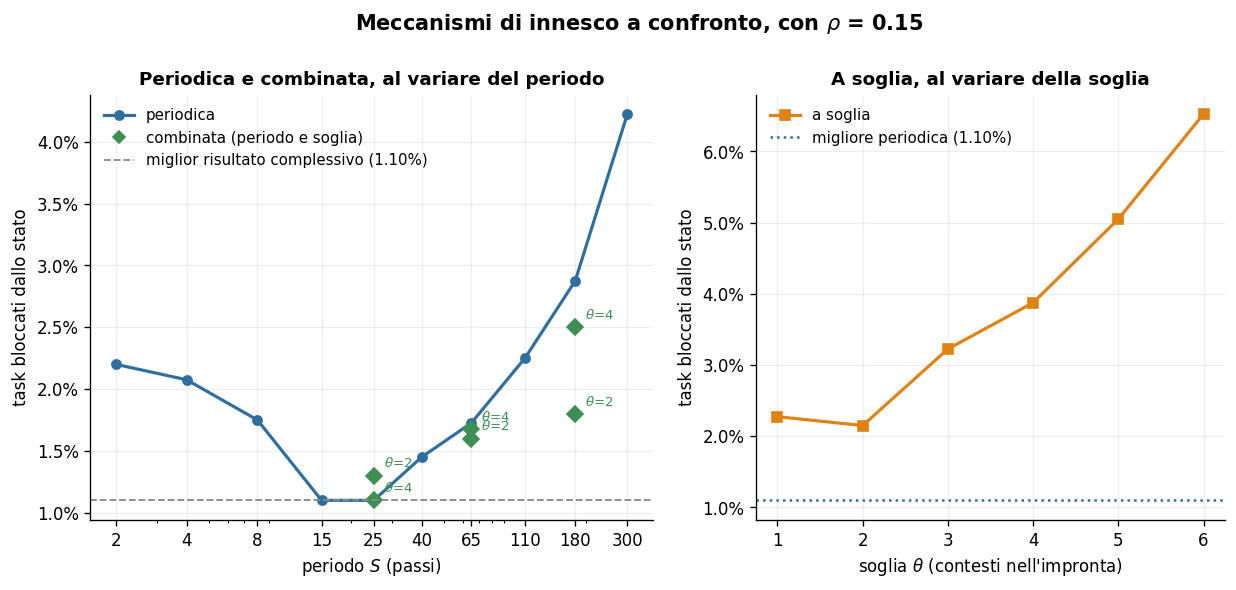

Confronto fra i meccanismi di innesco, densità dei conflitti 0.15

  periodica migliore    S = 15                   1.10%
  a soglia migliore     theta = 2                2.15%
  combinata migliore    S = 25, theta = 4            1.10%

Dettaglio della strategia combinata:

 periodo S  soglia theta  task bloccati
        25             2         0.0130
        25             4         0.0110
        65             2         0.0160
        65             4         0.0168
       180             2         0.0180
       180             4         0.0250


In [10]:
RHO_CONFRONTO = sorted(d.conflict_density.unique())[1]

ps_tutti = per_seme(d, ["strategy", "period", "threshold", "conflict_density"],
                    dict(bloccati=("blocked_by_state", "mean")))
sub = ps_tutti[ps_tutti.conflict_density == RHO_CONFRONTO]
agg = sub.groupby(["strategy", "period", "threshold"]).bloccati.median().reset_index()

per_p = agg[agg.strategy == "periodic"].sort_values("period")
per_t = agg[agg.strategy == "threshold"].sort_values("threshold")
per_c = agg[agg.strategy == "combined"].sort_values(["period", "threshold"])
migliore = agg.bloccati.min()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.2, 4.6),
                               gridspec_kw={"width_ratios": [1.2, 1]})

ax1.plot(per_p.period, per_p.bloccati, "-o", color=BLU, label="periodica")
for _, r in per_c.iterrows():
    ax1.plot(r.period, r.bloccati, "D", color=VERDE, markersize=7)
    ax1.annotate(f"$\\theta$={int(r.threshold)}", (r.period, r.bloccati),
                 textcoords="offset points", xytext=(6, 5), fontsize=8,
                 color=VERDE)
ax1.plot([], [], "D", color=VERDE, label="combinata (periodo e soglia)")
ax1.axhline(migliore, color=GRIGIO, linestyle="--", linewidth=1.1,
            label=f"miglior risultato complessivo ({migliore:.2%})")
ax1.set_xscale("log")
ax1.set_xticks(periodi)
ax1.set_xticklabels(periodi)
ax1.set_xlabel("periodo $S$ (passi)")
ax1.set_ylabel("task bloccati dallo stato")
asse_percentuale(ax1, decimals=1)
ax1.legend(loc="upper left")
ax1.set_title("Periodica e combinata, al variare del periodo")

ax2.plot(per_t.threshold, per_t.bloccati, "-s", color=ARANCIO, label="a soglia")
ax2.axhline(per_p.bloccati.min(), color=BLU, linestyle=":", linewidth=1.5,
            label=f"migliore periodica ({per_p.bloccati.min():.2%})")
ax2.set_xlabel("soglia $\\theta$ (contesti nell'impronta)")
ax2.set_ylabel("task bloccati dallo stato")
ax2.set_xticks(sorted(per_t.threshold.astype(int)))
asse_percentuale(ax2, decimals=1)
ax2.legend(loc="best")
ax2.set_title("A soglia, al variare della soglia")

fig.suptitle(f"Meccanismi di innesco a confronto, con $\\rho$ = {RHO_CONFRONTO}",
             y=1.03, fontsize=12.5, fontweight="semibold")
salva(fig, "sanificazione_inneschi")
plt.show()

riga_c = per_c.loc[per_c.bloccati.idxmin()]
print(f"Confronto fra i meccanismi di innesco, densità dei conflitti "
      f"{RHO_CONFRONTO}\n")
print(f"  periodica migliore    S = {int(per_p.loc[per_p.bloccati.idxmin()].period):<3}"
      f"                  {per_p.bloccati.min():.2%}")
print(f"  a soglia migliore     theta = {int(per_t.loc[per_t.bloccati.idxmin()].threshold):<3}"
      f"              {per_t.bloccati.min():.2%}")
print(f"  combinata migliore    S = {int(riga_c.period)}, theta = {int(riga_c.threshold):<3}"
      f"          {riga_c.bloccati:.2%}")
print("\nDettaglio della strategia combinata:\n")
det = per_c[["period", "threshold", "bloccati"]].copy()
det.columns = ["periodo S", "soglia theta", "task bloccati"]
print(det.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

**Come leggere il grafico.** Nel pannello di sinistra la strategia periodica in funzione
del periodo, con sovrapposti i punti della strategia combinata, ciascuno etichettato con
la soglia impiegata. Nel pannello di destra la strategia a soglia in funzione della
soglia, con una linea di riferimento che riporta il miglior risultato ottenuto dalla
strategia periodica, così da collocare immediatamente ciascuna configurazione rispetto
all'alternativa.

**Risultato.** I meccanismi puri hanno comportamenti qualitativamente diversi. La
strategia periodica presenta il compromesso già descritto, con un minimo interno
all'intervallo. La strategia a soglia degrada in modo sostanzialmente monotono al
crescere di $\theta$, poiché soglie alte lasciano crescere l'impronta prima di
intervenire, e nessuna delle sue configurazioni raggiunge il risultato della migliore
periodica: anche la soglia più efficace resta circa il doppio peggiore.

La strategia combinata eguaglia la migliore configurazione periodica ma non la supera.
Il motivo è che, una volta scelto un periodo prossimo all'ottimo, la componente
periodica interviene già abbastanza spesso da impedire alle impronte di raggiungere la
soglia, e il criterio aggiuntivo resta perlopiù inattivo. Il suo contributo diventa
invece visibile quando il periodo è lungo: nella regione dei periodi elevati la
combinata recupera una parte consistente del degrado della periodica pura, perché la
soglia interviene sui nodi che si contaminano più in fretta senza attendere la scadenza.

**Conclusione.** Il meccanismo di innesco incide meno della corretta calibrazione del
parametro che lo governa. Ciò che determina il risultato è la frequenza effettiva con
cui i nodi vengono ripuliti, e un periodo fisso ben scelto la controlla in modo diretto
e prevedibile. Il risultato sostiene la scelta implementativa adottata nel prototipo,
che impiega la sanificazione periodica: la sua semplicità non comporta una perdita di
efficacia, purché il periodo sia calibrato. La strategia combinata resta preferibile
quando il periodo non possa essere accorciato per ragioni operative, poiché in quel
regime la soglia limita il degrado; la strategia a soglia da sola non è invece mai
competitiva, perché non pone alcun limite alla permanenza delle tracce sui nodi poco
contaminati.

## Ridondanza dei nodi come mitigazione

**Che cosa si misura.** Il modello propone la ridondanza orizzontale, ovvero la presenza
di più nodi equivalenti per classe di proprietà e località, come mitigazione contro il
blocco da conflitto di interesse. L'intuizione è che se un nodo porta una traccia in
conflitto ne esista un altro pulito e altrettanto idoneo. Si verifica se e in quale
misura la mitigazione funzioni.

**Configurazione di partenza.** Configurazione di riferimento, cluster realistico,
duemila task per esecuzione, sanificazione periodica con periodo pari a cinquanta passi.
La densità dei conflitti è fissata a 0.2 per isolare l'effetto della scala.

**Che cosa varia.** Il fattore di replica del cluster, da uno a otto, nelle stesse due
modalità di replica dei dati introdotte nella Parte I.

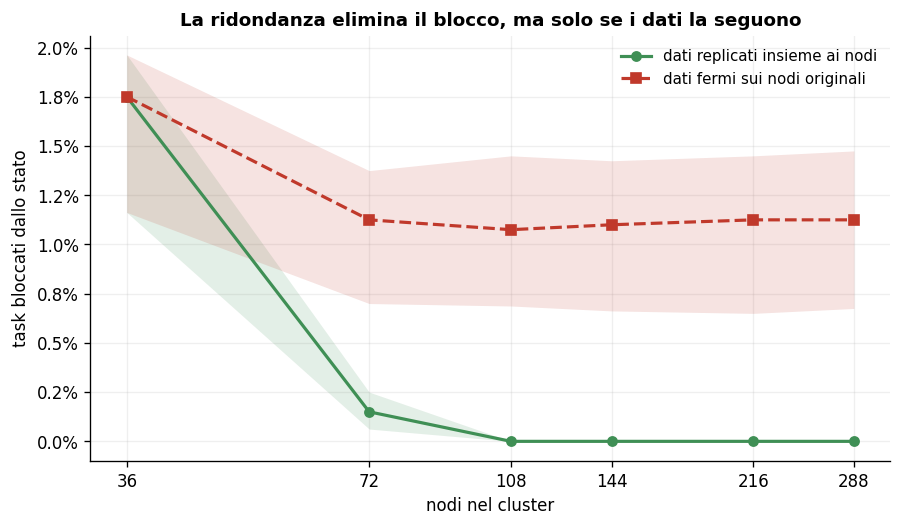

Task bloccati al crescere del cluster, mediana su 10 semi

                                   bloccati dallo stato  per conflitto
dati replicati fattore di replica                                     
False          1                                 0.0175         0.0125
               2                                 0.0112         0.0082
               3                                 0.0107         0.0080
               4                                 0.0110         0.0075
               6                                 0.0112         0.0082
               8                                 0.0112         0.0080
True           1                                 0.0175         0.0125
               2                                 0.0015         0.0010
               3                                 0.0000         0.0000
               4                                 0.0000         0.0000
               6                                 0.0000         0.0000
               8  

In [11]:
d = load("redundancy_tasks")
ps = per_seme(d, ["data_follows_nodes", "replication_factor"], dict(
    bloccati=("blocked_by_state", "mean"),
    per_conflitto=("causa_wall", "mean"),
    nodi=("n_nodes", "mean"),
))

fattori = sorted(ps.replication_factor.unique())
NODI_TEMPLATE = int(ps.nodi.min())

fig, ax = plt.subplots(figsize=(8.6, 4.6))
for segue, label, colour, style, marker in (
        (True, "dati replicati insieme ai nodi", VERDE, "-", "o"),
        (False, "dati fermi sui nodi originali", ROSSO, "--", "s")):
    sub = ps[ps.data_follows_nodes == segue]
    curva(ax, sub, "replication_factor", "bloccati", colour, label,
          marker=marker, style=style)

ax.set_xscale("log", base=2)
ax.set_xticks(fattori)
ax.set_xticklabels([str(NODI_TEMPLATE * f) for f in fattori])
ax.set_xlabel("nodi nel cluster")
ax.set_ylabel("task bloccati dallo stato")
asse_percentuale(ax, decimals=1)
ax.legend(loc="upper right")
ax.set_title("La ridondanza elimina il blocco, ma solo se i dati la seguono")
salva(fig, "ridondanza")
plt.show()

tab = ps.groupby(["data_follows_nodes", "replication_factor"])[
    ["bloccati", "per_conflitto"]].median()
tab.index.names = ["dati replicati", "fattore di replica"]
tab.columns = ["bloccati dallo stato", "per conflitto"]
print("Task bloccati al crescere del cluster, mediana su 10 semi\n")
print(tab.round(4))

**Come leggere il grafico.** Le due curve riportano la frazione di task bloccati dallo
stato al crescere del cluster. La curva continua corrisponde alla modalità in cui i dati
vengono replicati insieme ai nodi, quella tratteggiata alla modalità in cui restano
fermi. L'asse orizzontale riporta direttamente il numero di nodi.

**Risultato.** La mitigazione funziona, ma a una condizione precisa. Se i dati seguono i
nodi, il blocco si riduce di un ordine di grandezza già al primo raddoppio e si annulla
completamente a partire da un fattore di replica pari a tre: esistono sempre abbastanza
nodi puliti ed equivalenti su cui collocare il task.

Se i dati restano fermi la curva si appiattisce quasi subito. Si ottiene un guadagno nel
primo raddoppio, dopo di che l'aggiunta di nodi non produce alcun ulteriore
miglioramento, nemmeno moltiplicando la dimensione per otto. Il motivo è quello
individuato nella Parte I: i task vincolati a dataset statici continuano a disporre dello
stesso insieme ristretto di nodi candidati, e sono esattamente quelli che restano
bloccati. Aggiungere nodi non li raggiunge.

**Conclusione.** La mitigazione proposta dal modello è valida ma va qualificata. Non è la
ridondanza dei nodi in quanto tale a proteggere dalla starvation, bensì la ridondanza dei
dati che la accompagna. In un cluster reale i due fattori vanno dimensionati
congiuntamente, e intervenire soltanto sullo strato di calcolo lascia scoperta proprio la
categoria di task più vincolata.

# Sintesi dei risultati

**Sullo spazio delle soluzioni.** Le politiche di configurazione restringono l'insieme
dei nodi ammissibili in misura sostanziale e cumulativa, e la restrizione cresce con il
numero di dataset che un task aggrega. L'effetto non dipende dalle distribuzioni adottate
ma dalla definizione degli operatori del modello: il requisito effettivo è un minimo
maggiorante e la giurisdizione effettiva è una intersezione, quindi ogni dataset aggiunto
può soltanto restringere l'insieme ammissibile. Le distribuzioni ne determinano la
pendenza, non la direzione. Le due composizioni di cluster confrontate si comportano in
modo qualitativamente identico, e il cluster stratificato conserva un vantaggio costante
grazie alla distribuzione omogenea delle classi.

**Sul costo di ciascuna proprietà.** Il vincolo sulle proprietà richiede la dominanza su
tutte le proprietà contemporaneamente, e la sua restrittività decade geometricamente nel
numero di proprietà definite, in accordo con la forma chiusa attesa sotto ipotesi di
indipendenza. Ogni proprietà aggiunta moltiplica l'ammissibilità per la quota di nodi che
raggiungono il livello richiesto su quella proprietà. Le proprietà astratte hanno quindi
un costo moltiplicativo e vanno introdotte con parsimonia.

**Sui dati statici.** Il rifiuto per intersezione vuota è il vincolo più severo del
modello e l'unico che nessuna quantità di nodi può risolvere. La replica dei dati lo
mitiga, ma il beneficio per copia aggiuntiva si manifesta solo oltre una certa soglia, e
va dimensionato in rapporto al numero di dataset statici che un task tipicamente combina.

**Sull'ingrandimento del cluster.** Aggiungere nodi mantiene costante la frazione di nodi
ammissibili per i task che non richiedono dati statici, quindi il pool cresce
proporzionalmente. Per i task vincolati a dati statici, invece, il numero assoluto di
candidati non cresce affatto se i dati non vengono replicati insieme ai nodi.

**Sulla dinamica dell'assegnazione.** Il blocco per conflitto di interesse cresce con la
densità dei conflitti in modo regolare e sublineare, e resta contenuto purché la
sanificazione sia attiva. Il periodo di sanificazione traccia un compromesso con un
minimo interno: sanificare troppo di rado lascia contaminare i nodi, sanificare troppo
spesso li sottrae all'insieme disponibile. La posizione dell'ottimo si sposta verso
periodi più brevi al crescere della densità dei conflitti, quindi il parametro va
calibrato tenendo conto dell'intensità della competizione attesa nell'ambiente.

**Sui meccanismi di innesco.** Nessun meccanismo alternativo supera una sanificazione
periodica ben calibrata. La strategia a soglia degrada al crescere della soglia, non pone
limiti alla durata di una traccia su un nodo poco contaminato e resta circa il doppio
peggiore della migliore periodica; la strategia combinata la eguaglia e diventa
preferibile solo quando il periodo non può essere accorciato. Il risultato sostiene la
scelta implementativa del prototipo.

**Sulle mitigazioni.** La ridondanza orizzontale dei nodi elimina il blocco per conflitto
di interesse, ma soltanto se accompagnata dalla replica dei dati; in caso contrario il
beneficio si esaurisce dopo il primo raddoppio del cluster, per la stessa ragione
osservata sui dataset statici. È il filo che unisce le due parti dell'analisi: il vincolo
alla scalabilità del modello risiede nello strato di memorizzazione dei dati, non in
quello di calcolo.

# Limitazioni

**Distribuzioni sintetiche.** I risultati valgono sotto le distribuzioni descritte nella
configurazione di riferimento, che vanno considerate parte delle ipotesi. Dove un
risultato dipende da una scelta distribuzionale ciò è indicato nella sezione relativa;
dove invece discende dalla struttura degli operatori del modello, come nella monotonia
dell'imbuto e nel decadimento geometrico del vincolo sulle proprietà, il risultato è
indipendente dalle distribuzioni e ne varia soltanto l'entità.

**Assenza di una scala temporale.** Il passo è una unità di conteggio e non di tempo.
Nessuna latenza assoluta è stimabile da questa analisi, e le grandezze espresse in passi,
come il periodo di sanificazione e la durata dei task, non sono direttamente convertibili
in unità di tempo. La misura delle latenze è oggetto della valutazione condotta sul
prototipo.

**Saturazione delle risorse non modellata.** Il modello non prevede alcun limite al
numero di task concorrenti su un nodo, e l'implementazione di riferimento ne tiene
traccia solo per riprodurre l'attesa che precede il completamento della sanificazione. In
un cluster reale la contesa per processore e memoria produrrebbe blocchi ulteriori,
gestiti in Kubernetes da meccanismi nativi esterni al contributo di questa tesi. I
risultati sui task bloccati vanno quindi letti come attribuibili alle sole politiche.

**Task bloccati non riaccodati.** Un task che non trova collocazione al proprio passo è
contato come bloccato e non viene riprovato. La misura riguarda l'ammissibilità
istantanea e non il tempo di attesa, che dipende dal comportamento della coda dello
scheduler ed è misurabile solo sul prototipo.

**Efficacia della sanificazione assunta.** La sanificazione è modellata come azzeramento
completo dell'impronta contestuale. La sua efficacia fisica nel rimuovere tracce residue
dai supporti di memorizzazione non è oggetto di questa valutazione.

**Vincolo geografico non isolato.** Come argomentato nella sezione relativa, la
restrittività intrinseca del vincolo geografico coincide con la quota di nodi collocati
nella giurisdizione richiesta, e isolarla avrebbe richiesto un parametro di concentrazione
geografica dei nodi che descrive l'infrastruttura anziché il modello. Il suo contributo
resta misurato come componente dell'imbuto e come frequenza dei rifiuti in traduzione.

**Numero di ripetizioni.** Ogni configurazione è ripetuta su dieci semi. Le bande
riportate nei grafici descrivono la dispersione osservata; un numero maggiore di
ripetizioni le restringerebbe senza modificare le mediane, poiché gli andamenti misurati
sono ampiamente separati rispetto alla dispersione.